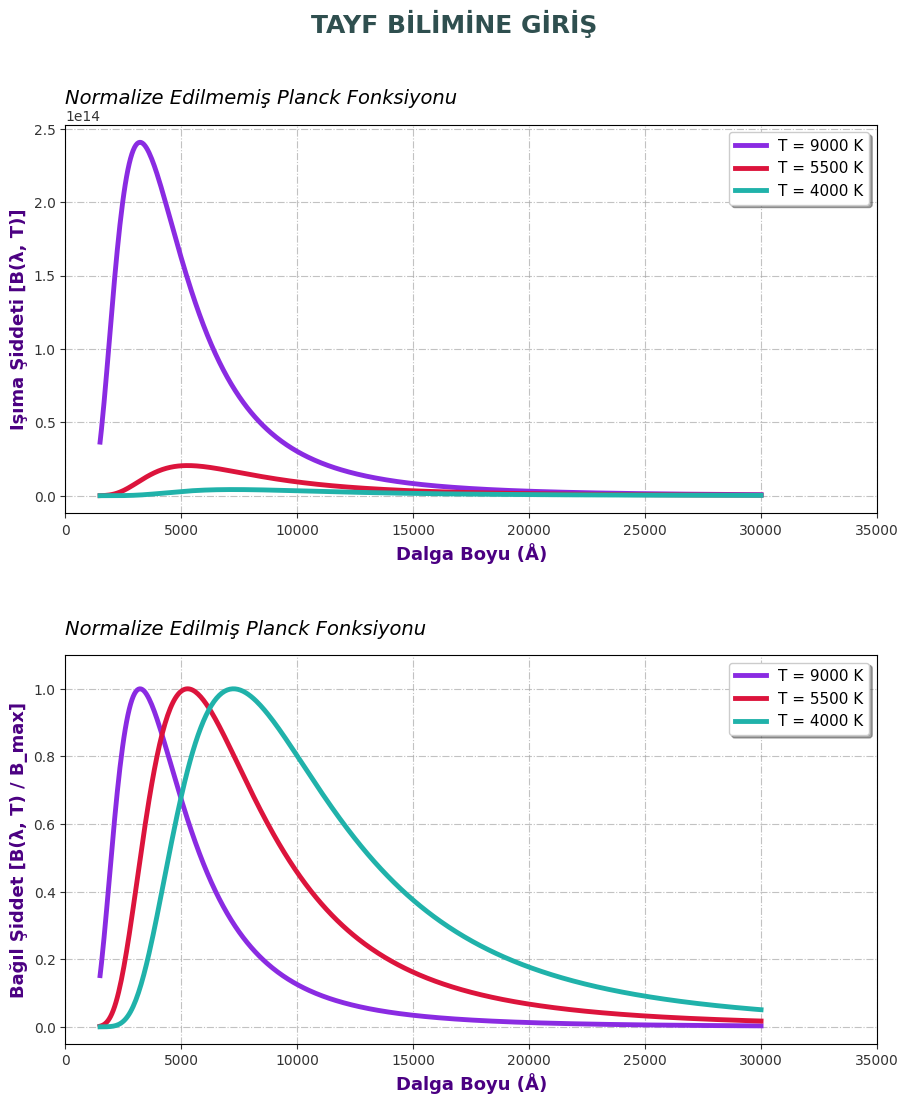

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Fiziksel sabitler
h = 6.626e-34  # Planck sabiti (J.s)
c = 3.0e8      # Işık hızı (m/s)
k = 1.38e-23   # Boltzmann sabiti (J/K)

def planck_fonksiyonu(dalga_boyu_angstrom, T):
    """Belirli bir dalga boyu ve sıcaklık için ışıma şiddetini hesaplar."""
    # Angstrom'u metreye çeviriyoruz
    dalga_boyu_m = dalga_boyu_angstrom * 1e-10
    
    pay = 2.0 * h * c**2
    payda = (dalga_boyu_m**5) * (np.exp((h * c) / (dalga_boyu_m * k * T)) - 1.0)
    return pay / payda

# X ekseni: 1500 ile 30000 Angstrom arası dalga boyları
dalga_boylari = np.linspace(1500, 30000, 500)

# Örnek sıcaklıklar ve YENİ görsel ayarlar
sicakliklar = [9000, 5500, 4000]
renkler = ['#8A2BE2', '#DC143C', '#20B2AA'] # Mor, Koyu Kırmızı, Turkuaz
etiketler = ['T = 9000 K', 'T = 5500 K', 'T = 4000 K']

# Figür oluşturma (İki grafiği alt alta koyuyoruz)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))
fig.suptitle('TAYF BİLİMİNE GİRİŞ', fontsize=18, fontweight='heavy', color='#2F4F4F', y=0.95)

# --- 1. Grafik: Normalize Edilmemiş Planck Fonksiyonu ---
for T, renk, etiket in zip(sicakliklar, renkler, etiketler):
    siddet = planck_fonksiyonu(dalga_boylari, T)
    ax1.plot(dalga_boylari, siddet, color=renk, linewidth=3.5, label=etiket, linestyle='-')

ax1.set_title('Normalize Edilmemiş Planck Fonksiyonu', fontsize=14, fontstyle='italic', loc='left', pad=15)
ax1.set_xlabel('Dalga Boyu (Å)', fontsize=13, fontweight='bold', color='#4B0082')
ax1.set_ylabel('Işıma Şiddeti [B(λ, T)]', fontsize=13, fontweight='bold', color='#4B0082')
ax1.grid(True, linestyle='-.', alpha=0.7, color='#A9A9A9') # Noktalı-çizgili ızgara
ax1.legend(fontsize=11, loc='upper right', frameon=True, shadow=True)
ax1.set_xlim(0, 35000)
ax1.tick_params(axis='both', which='major', labelsize=10, colors='#333333')

# --- 2. Grafik: Normalize Edilmiş Planck Fonksiyonu ---
for T, renk, etiket in zip(sicakliklar, renkler, etiketler):
    siddet = planck_fonksiyonu(dalga_boylari, T)
    # Değerleri kendi tepe noktasına bölerek [0, 1] aralığına çekiyoruz
    normalize_siddet = siddet / np.max(siddet)
    ax2.plot(dalga_boylari, normalize_siddet, color=renk, linewidth=3.5, label=etiket, linestyle='-')

ax2.set_title('Normalize Edilmiş Planck Fonksiyonu', fontsize=14, fontstyle='italic', loc='left', pad=15)
ax2.set_xlabel('Dalga Boyu (Å)', fontsize=13, fontweight='bold', color='#4B0082')
ax2.set_ylabel('Bağıl Şiddet [B(λ, T) / B_max]', fontsize=13, fontweight='bold', color='#4B0082')
ax2.grid(True, linestyle='-.', alpha=0.7, color='#A9A9A9')
ax2.legend(fontsize=11, loc='upper right', frameon=True, shadow=True)
ax2.set_xlim(0, 35000)
ax2.set_ylim(-0.05, 1.1) # Y eksenini biraz boşluklu bırakıyoruz
ax2.tick_params(axis='both', which='major', labelsize=10, colors='#333333')

# Grafikler arası boşluğu ayarla
plt.tight_layout(pad=4.0)
plt.show()

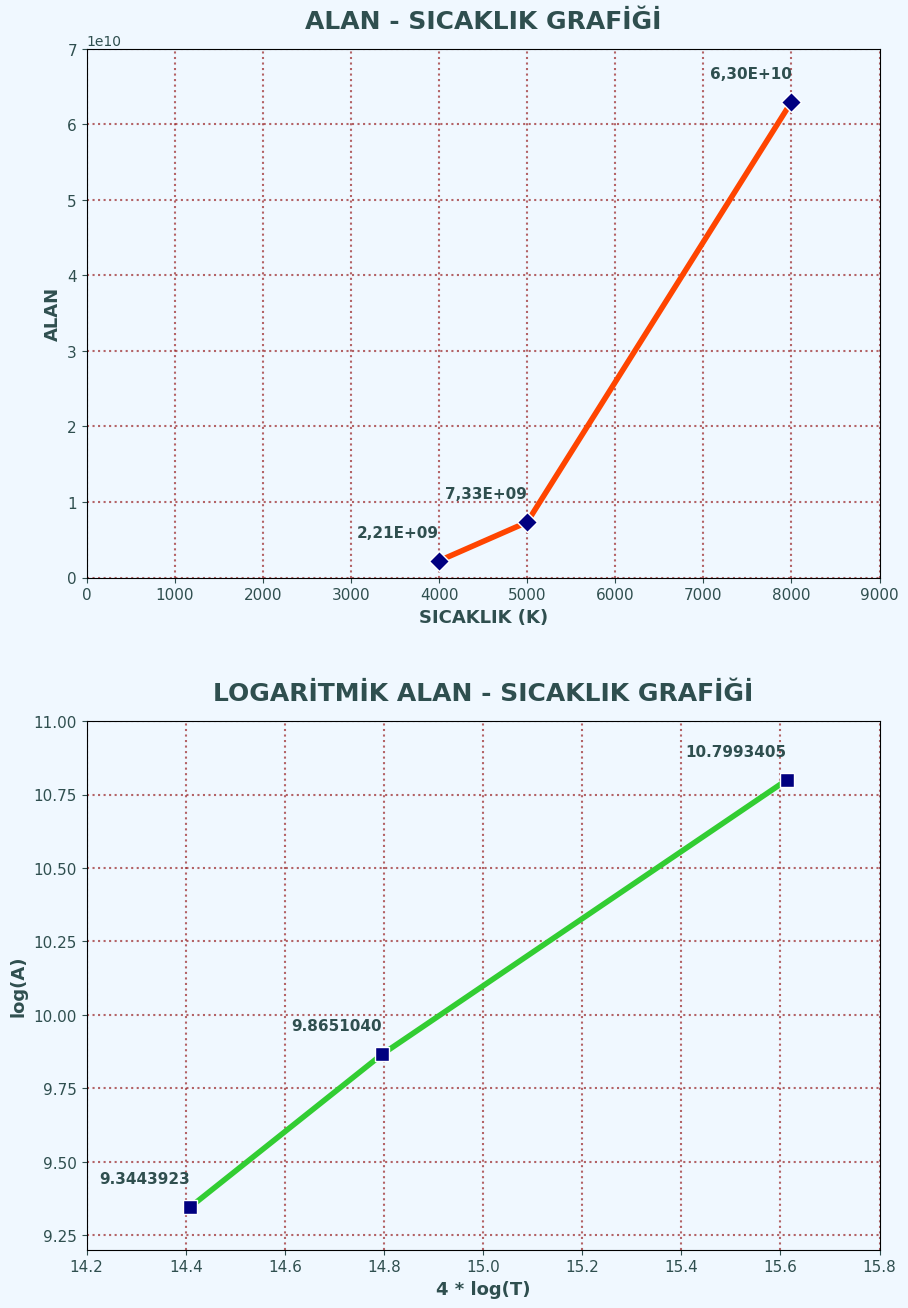

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# --- Veri Hazırlığı ---
sicaklik = np.array([4000, 5000, 8000])
alan = np.array([2.21e9, 7.33e9, 6.30e10])

# İkinci grafik için logaritmik hesaplamalar (Taban 10)
# Sorudaki "log A α 4 log T" ilişkisine göre:
x_log = 4 * np.log10(sicaklik)
y_log = np.log10(alan)

# --- Görsel Ayarlar ---
arkaplan_rengi = '#F0F8FF'  # Açık Mavi (Alice Blue)
cizgi_rengi_1 = '#FF4500'   # Turuncu/Kırmızı (Orange Red)
cizgi_rengi_2 = '#32CD32'   # Limon Yeşili (Lime Green)
nokta_rengi = '#000080'     # Lacivert (Navy)

# Figür ve Alt Grafikleri (Subplots) Oluşturma
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 14))
fig.patch.set_facecolor(arkaplan_rengi)

# ==========================================
# 1. GRAFİK: ALAN - SICAKLIK GRAFİĞİ
# ==========================================
ax1.set_facecolor(arkaplan_rengi)
ax1.plot(sicaklik, alan, color=cizgi_rengi_1, linewidth=4, 
         marker='D', markersize=10, markerfacecolor=nokta_rengi, markeredgecolor='white')

# 1. Grafik Etiketleri
etiketler_1 = ['2,21E+09', '7,33E+09', '6,30E+10']
for x, y, etiket in zip(sicaklik, alan, etiketler_1):
    ax1.annotate(etiket, xy=(x, y), xytext=(0, 15), textcoords='offset points', 
                 ha='right', va='bottom', fontsize=11, fontweight='bold', color='#2F4F4F')

ax1.set_title('ALAN - SICAKLIK GRAFİĞİ', fontsize=18, fontweight='black', color='#2F4F4F', pad=15)
ax1.set_xlabel('SICAKLIK (K)', fontsize=13, fontweight='bold', color='#2F4F4F')
ax1.set_ylabel('ALAN', fontsize=13, fontweight='bold', color='#2F4F4F')
ax1.set_xlim(0, 9000)
ax1.set_ylim(0, 7.0e10)
ax1.grid(True, linestyle=':', linewidth=1.5, alpha=0.6, color='#8B0000') # Koyu kırmızı noktalı grid
ax1.tick_params(axis='both', labelsize=11, colors='#2F4F4F')

# ==========================================
# 2. GRAFİK: LOGARİTMİK ALAN - SICAKLIK GRAFİĞİ
# ==========================================
ax2.set_facecolor(arkaplan_rengi)
ax2.plot(x_log, y_log, color=cizgi_rengi_2, linewidth=4, 
         marker='s', markersize=10, markerfacecolor=nokta_rengi, markeredgecolor='white')

# 2. Grafik Etiketleri (Yuvarlatılmış değerler kullanıyoruz ki görsel çok kalabalık olmasın)
for x, y in zip(x_log, y_log):
    etiket_metni = f"{y:.7f}" 
    ax2.annotate(etiket_metni, xy=(x, y), xytext=(0, 15), textcoords='offset points', 
                 ha='right', va='bottom', fontsize=11, fontweight='bold', color='#2F4F4F')

ax2.set_title('LOGARİTMİK ALAN - SICAKLIK GRAFİĞİ', fontsize=18, fontweight='black', color='#2F4F4F', pad=15)
ax2.set_xlabel('4 * log(T)', fontsize=13, fontweight='bold', color='#2F4F4F')
ax2.set_ylabel('log(A)', fontsize=13, fontweight='bold', color='#2F4F4F')

# Eksen sınırlarını orijinaline benzetelim
ax2.set_xlim(14.2, 15.8)
ax2.set_ylim(9.2, 11)
ax2.grid(True, linestyle=':', linewidth=1.5, alpha=0.6, color='#8B0000')
ax2.tick_params(axis='both', labelsize=11, colors='#2F4F4F')

# Grafikler arası boşluğu ayarla
plt.tight_layout(pad=4.0)
plt.show()

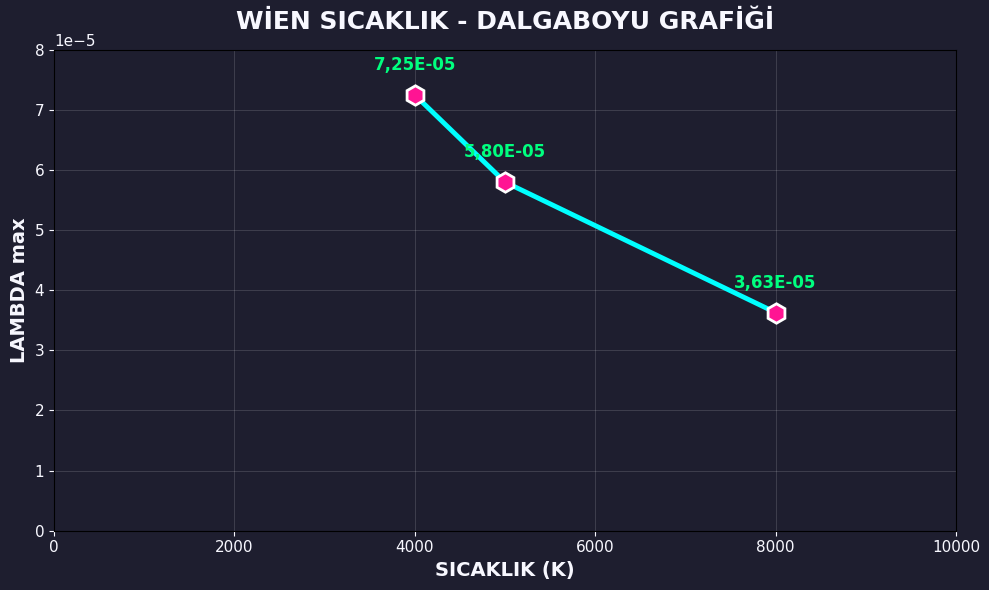

In [5]:
import matplotlib.pyplot as plt

# Veriler (Grafikten okunan Sıcaklık ve Lambda max değerleri)
sicaklik = [4000, 5000, 8000]
lambda_max = [7.25e-5, 5.80e-5, 3.63e-5]

# Tamamen farklı, koyu temalı görsel stil
arkaplan_rengi = '#1E1E2F' # Koyu lacivert/gri (Dark background)
cizgi_rengi = '#00FFFF'    # Camgöbeği (Cyan)
nokta_rengi = '#FF1493'    # Derin Pembe (Deep Pink)
yazi_rengi = '#F8F8FF'     # Hayalet Beyazı

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(arkaplan_rengi)
ax.set_facecolor(arkaplan_rengi)

# Eğri ve noktaların çizimi (Kalın neon tarzı çizgiler ve altıgen noktalar)
ax.plot(sicaklik, lambda_max, color=cizgi_rengi, linewidth=3.5, 
        marker='h', markersize=14, markerfacecolor=nokta_rengi, 
        markeredgecolor='white', markeredgewidth=2)

# Değer etiketlerini yeşil neon tonunda ekleme
etiketler = ['7,25E-05', '5,80E-05', '3,63E-05']
for x, y, etiket in zip(sicaklik, lambda_max, etiketler):
    ax.annotate(etiket, xy=(x, y), xytext=(0, 15), textcoords='offset points', 
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='#00FF7F')

# Başlık ve eksenler
ax.set_title('WİEN SICAKLIK - DALGABOYU GRAFİĞİ', fontsize=18, fontweight='bold', color=yazi_rengi, pad=15)
ax.set_xlabel('SICAKLIK (K)', fontsize=14, fontweight='bold', color=yazi_rengi)
ax.set_ylabel('LAMBDA max', fontsize=14, fontweight='bold', color=yazi_rengi)

# Eksen sınırları (Orijinal grafiğe sadık kalarak)
ax.set_xlim(0, 10000)
ax.set_ylim(0, 8.00e-5)

# Izgara ayarları (Sadece çok hafif belli olan düz çizgiler)
ax.grid(True, linestyle='-', linewidth=0.5, alpha=0.2, color='#FFFFFF')

# Eksen sayılarının stili
ax.tick_params(axis='both', colors=yazi_rengi, labelsize=11)
ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax.yaxis.get_offset_text().set_color(yazi_rengi)
ax.yaxis.get_offset_text().set_fontsize(11)

plt.tight_layout()
plt.show()

--- Teorik Renk İndeksi Oranları (-2.5 * log(F1/F2)) ---
Sıcaklık: 9000 K -> U-B: -0.24, B-V: -0.36
Sıcaklık: 5500 K -> U-B: 0.44, B-V: 0.07
Sıcaklık: 4000 K -> U-B: 1.12, B-V: 0.49


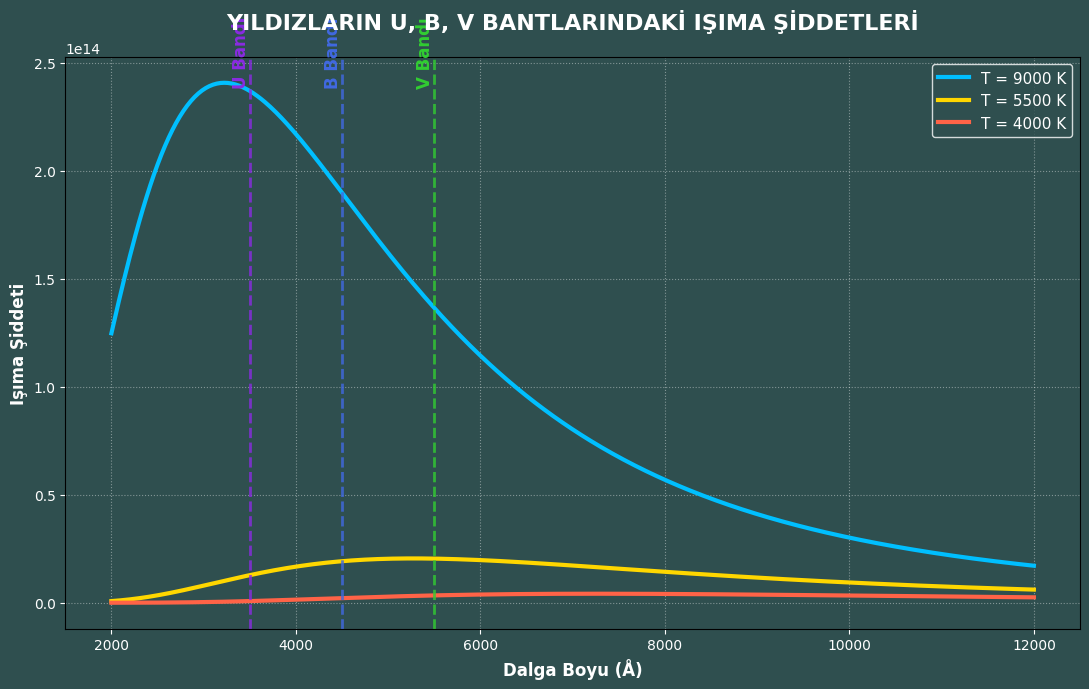

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Fiziksel sabitler
h = 6.626e-34
c = 3.0e8
k = 1.38e-23

def planck_fonksiyonu(dalga_boyu_angstrom, T):
    dalga_boyu_m = dalga_boyu_angstrom * 1e-10
    pay = 2.0 * h * c**2
    payda = (dalga_boyu_m**5) * (np.exp((h * c) / (dalga_boyu_m * k * T)) - 1.0)
    return pay / payda

# X ekseni: Görünür bölgeye ve UV'ye odaklanmak için aralığı daralttık
dalga_boylari = np.linspace(2000, 12000, 500)

sicakliklar = [9000, 5500, 4000]
cizgi_renkleri = ['#00BFFF', '#FFD700', '#FF6347'] # Derin Gök Mavisi, Altın, Domates Kırmızısı
etiketler = ['T = 9000 K', 'T = 5500 K', 'T = 4000 K']

# Fotometrik Bantlar (U, B, V)
wav_U, wav_B, wav_V = 3500, 4500, 5500
bant_renkleri = {'U (3500 Å)': '#8A2BE2', 'B (4500 Å)': '#4169E1', 'V (5500 Å)': '#32CD32'}

# --- RENK İNDEKSİ HESAPLAMALARI ---
print("--- Teorik Renk İndeksi Oranları (-2.5 * log(F1/F2)) ---")
for T in sicakliklar:
    F_U = planck_fonksiyonu(wav_U, T)
    F_B = planck_fonksiyonu(wav_B, T)
    F_V = planck_fonksiyonu(wav_V, T)
    
    # Sabitleri ihmal ederek sadece oranlardan gelen teorik farklar
    U_B = -2.5 * np.log10(F_U / F_B)
    B_V = -2.5 * np.log10(F_B / F_V)
    
    print(f"Sıcaklık: {T} K -> U-B: {U_B:.2f}, B-V: {B_V:.2f}")

# --- GRAFİK ÇİZİMİ ---
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#2F4F4F') # Koyu arduvaz grisi
ax.set_facecolor('#2F4F4F')

# Planck eğrileri
for T, renk, etiket in zip(sicakliklar, cizgi_renkleri, etiketler):
    siddet = planck_fonksiyonu(dalga_boylari, T)
    ax.plot(dalga_boylari, siddet, color=renk, linewidth=3, label=etiket)

# U, B, V bantlarını dikey çizgilerle gösterme
y_max = ax.get_ylim()[1]
ax.axvline(x=wav_U, color=bant_renkleri['U (3500 Å)'], linestyle='--', linewidth=2, alpha=0.8)
ax.axvline(x=wav_B, color=bant_renkleri['B (4500 Å)'], linestyle='--', linewidth=2, alpha=0.8)
ax.axvline(x=wav_V, color=bant_renkleri['V (5500 Å)'], linestyle='--', linewidth=2, alpha=0.8)

# Bant isimlerini grafiğin üstüne yazma
ax.text(wav_U, y_max * 0.95, 'U Bandı', color=bant_renkleri['U (3500 Å)'], fontsize=12, fontweight='bold', ha='right', rotation=90)
ax.text(wav_B, y_max * 0.95, 'B Bandı', color=bant_renkleri['B (4500 Å)'], fontsize=12, fontweight='bold', ha='right', rotation=90)
ax.text(wav_V, y_max * 0.95, 'V Bandı', color=bant_renkleri['V (5500 Å)'], fontsize=12, fontweight='bold', ha='right', rotation=90)

ax.set_title('YILDIZLARIN U, B, V BANTLARINDAKİ IŞIMA ŞİDDETLERİ', fontsize=16, fontweight='bold', color='white', pad=20)
ax.set_xlabel('Dalga Boyu (Å)', fontsize=12, fontweight='bold', color='white')
ax.set_ylabel('Işıma Şiddeti', fontsize=12, fontweight='bold', color='white')

ax.grid(True, linestyle=':', alpha=0.4, color='white')
ax.tick_params(axis='both', colors='white')
ax.legend(fontsize=11, loc='upper right', facecolor='#2F4F4F', edgecolor='white', labelcolor='white')

plt.tight_layout()
plt.show()

--- Teorik Renk İndeksi Oranları (-2.5 * log(F1/F2)) ---
Sıcaklık: 9000 K -> U-B: -0.24, B-V: -0.36
Sıcaklık: 5500 K -> U-B: 0.44, B-V: 0.07
Sıcaklık: 4000 K -> U-B: 1.12, B-V: 0.49


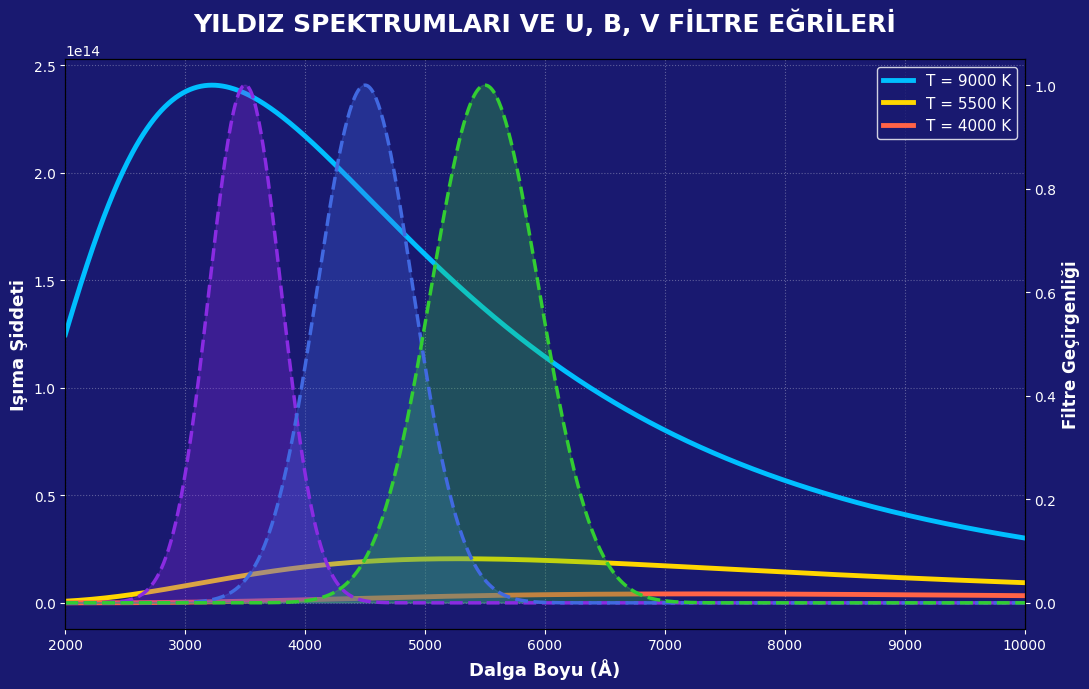

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Fiziksel sabitler
h = 6.626e-34
c = 3.0e8
k = 1.38e-23

def planck_fonksiyonu(dalga_boyu_angstrom, T):
    """Belirli bir dalga boyu ve sıcaklık için ışıma şiddetini hesaplar."""
    dalga_boyu_m = dalga_boyu_angstrom * 1e-10
    pay = 2.0 * h * c**2
    payda = (dalga_boyu_m**5) * (np.exp((h * c) / (dalga_boyu_m * k * T)) - 1.0)
    return pay / payda

def filtre_egrisi(dalga_boyu, merkez, genislik):
    """Basit bir Gauss eğrisi ile filtre geçirgenliğini modeller."""
    return np.exp(-((dalga_boyu - merkez)**2) / (2 * genislik**2))

# X ekseni: 2000 ile 12000 Angstrom arası dalga boyları (Görünür + UV)
dalga_boylari = np.linspace(2000, 12000, 1000)

# Sıcaklıklar
sicakliklar = [9000, 5500, 4000]
cizgi_renkleri = ['#00BFFF', '#FFD700', '#FF6347'] # Derin Gök Mavisi, Altın, Domates Kırmızısı
etiketler = ['T = 9000 K', 'T = 5500 K', 'T = 4000 K']

# Fotometrik Filtreler (U, B, V) - Merkez ve yaklaşık genişlikler
bantlar = {
    'U (UV)': {'merkez': 3500, 'genislik': 300, 'renk': '#8A2BE2', 'etiket': 'U Filtresi'},
    'B (Mavi)': {'merkez': 4500, 'genislik': 400, 'renk': '#4169E1', 'etiket': 'B Filtresi'},
    'V (Görünür)': {'merkez': 5500, 'genislik': 450, 'renk': '#32CD32', 'etiket': 'V Filtresi'}
}

# --- RENK İNDEKSİ HESAPLAMALARI (Teorik Fark Oranları) ---
print("--- Teorik Renk İndeksi Oranları (-2.5 * log(F1/F2)) ---")
for T in sicakliklar:
    F_U = planck_fonksiyonu(bantlar['U (UV)']['merkez'], T)
    F_B = planck_fonksiyonu(bantlar['B (Mavi)']['merkez'], T)
    F_V = planck_fonksiyonu(bantlar['V (Görünür)']['merkez'], T)
    
    U_B = -2.5 * np.log10(F_U / F_B)
    B_V = -2.5 * np.log10(F_B / F_V)
    
    print(f"Sıcaklık: {T} K -> U-B: {U_B:.2f}, B-V: {B_V:.2f}")

# --- GRAFİK ÇİZİMİ ---
fig, ax1 = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#191970') # Gece mavisi arkaplan
ax1.set_facecolor('#191970')

# Planck eğrileri (Kalın çizgiler)
for T, renk, etiket in zip(sicakliklar, cizgi_renkleri, etiketler):
    siddet = planck_fonksiyonu(dalga_boylari, T)
    ax1.plot(dalga_boylari, siddet, color=renk, linewidth=3.5, label=etiket)

# İkinci Y ekseni (Filtre geçirgenliği için)
ax2 = ax1.twinx()
ax2.set_ylabel('Filtre Geçirgenliği', color='white', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', colors='white')

# Filtre eğrileri (Kesikli çizgiler ve yarı saydam alanlar)
for bant_adi, bant_verisi in bantlar.items():
    gecirgenlik = filtre_egrisi(dalga_boylari, bant_verisi['merkez'], bant_verisi['genislik'])
    ax2.plot(dalga_boylari, gecirgenlik, color=bant_verisi['renk'], linestyle='--', linewidth=2.5)
    ax2.fill_between(dalga_boylari, gecirgenlik, alpha=0.3, color=bant_verisi['renk'], label=bant_verisi['etiket'])

# Başlık ve Eksenler
ax1.set_title('YILDIZ SPEKTRUMLARI VE U, B, V FİLTRE EĞRİLERİ', fontsize=18, fontweight='black', color='white', pad=20)
ax1.set_xlabel('Dalga Boyu (Å)', fontsize=13, fontweight='bold', color='white')
ax1.set_ylabel('Işıma Şiddeti', fontsize=13, fontweight='bold', color='white')

# Izgara, Eksen Sınırları ve Tick Ayarları
ax1.grid(True, linestyle=':', alpha=0.3, color='white')
ax1.tick_params(axis='both', colors='white')
ax1.set_xlim(2000, 10000)

# Legend (Gösterge) - Planck eğrileri için
ax1.legend(fontsize=11, loc='upper right', facecolor='#191970', edgecolor='white', labelcolor='white')

plt.tight_layout()
plt.show()

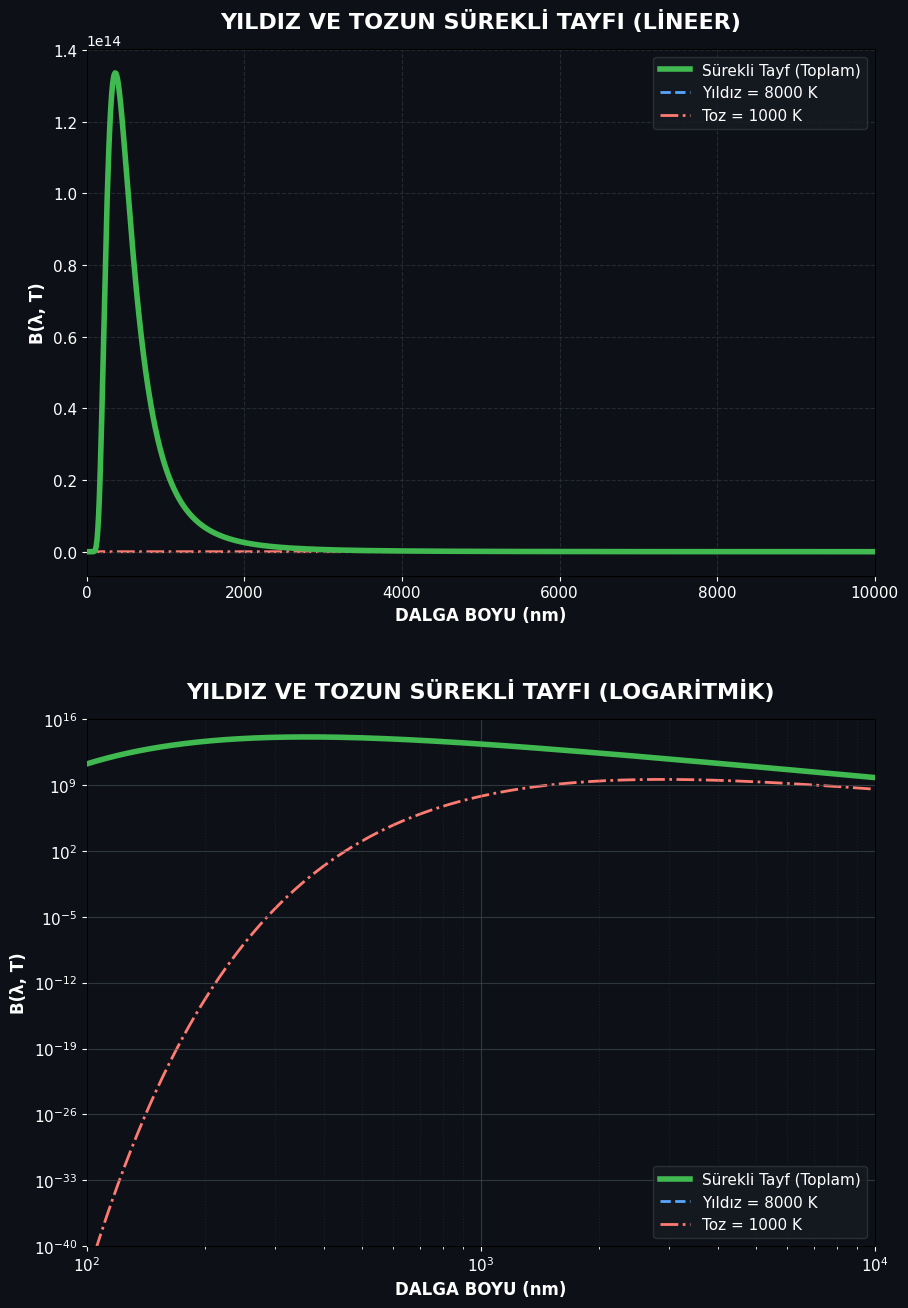

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Fiziksel sabitler
h = 6.626e-34
c = 3.0e8
k = 1.38e-23

def planck_fonksiyonu(dalga_boyu_nm, T):
    """Dalga boyunu nm cinsinden alıp ışıma şiddetini hesaplar."""
    dalga_boyu_m = dalga_boyu_nm * 1e-9
    pay = 2.0 * h * c**2
    
    # Çok düşük sıcaklık ve kısa dalga boylarında üslü sayının 
    # patlamasını (Overflow) engellemek için sınırlandırma yapıyoruz
    ust = np.clip((h * c) / (dalga_boyu_m * k * T), None, 700)
    payda = (dalga_boyu_m**5) * (np.exp(ust) - 1.0)
    return pay / payda

# Dalga boyu dizileri (Biri lineer diğeri logaritmik grafik için)
dalga_boylari_lineer = np.linspace(10, 10000, 1000)
dalga_boylari_log = np.logspace(2, 4, 1000) # 100 nm (10^2) ile 10000 nm (10^4) arası

# Yepyeni Siber-Uzay / Dark Mode Renk Paleti
arkaplan = '#0D1117'    # GitHub Dark arkaplanı
renk_yildiz = '#58A6FF' # Neon Mavi
renk_toz = '#FF7B72'    # Neon Somon/Kırmızı
renk_toplam = '#3FB950' # Neon Yeşil

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 14))
fig.patch.set_facecolor(arkaplan)

# ==========================================
# 1. GRAFİK: LİNEER ÖLÇEK
# ==========================================
ax1.set_facecolor(arkaplan)

B_yildiz_lin = planck_fonksiyonu(dalga_boylari_lineer, 8000)
B_toz_lin = planck_fonksiyonu(dalga_boylari_lineer, 1000)
B_toplam_lin = B_yildiz_lin + B_toz_lin

ax1.plot(dalga_boylari_lineer, B_toplam_lin, color=renk_toplam, linewidth=4, label='Sürekli Tayf (Toplam)', zorder=3)
ax1.plot(dalga_boylari_lineer, B_yildiz_lin, color=renk_yildiz, linewidth=2, linestyle='--', label='Yıldız = 8000 K', zorder=2)
ax1.plot(dalga_boylari_lineer, B_toz_lin, color=renk_toz, linewidth=2, linestyle='-.', label='Toz = 1000 K', zorder=1)

ax1.set_title('YILDIZ VE TOZUN SÜREKLİ TAYFI (LİNEER)', fontsize=16, fontweight='black', color='white', pad=15)
ax1.set_xlabel('DALGA BOYU (nm)', fontsize=12, fontweight='bold', color='white')
ax1.set_ylabel('B(λ, T)', fontsize=12, fontweight='bold', color='white')
ax1.grid(True, color='#30363D', linestyle='--', alpha=0.7)
ax1.tick_params(colors='white', labelsize=11)
ax1.legend(facecolor='#161B22', edgecolor='#30363D', labelcolor='white', fontsize=11)
ax1.set_xlim(0, 10000)

# ==========================================
# 2. GRAFİK: LOGARİTMİK ÖLÇEK
# ==========================================
ax2.set_facecolor(arkaplan)

B_yildiz_log = planck_fonksiyonu(dalga_boylari_log, 8000)
B_toz_log = planck_fonksiyonu(dalga_boylari_log, 1000)
B_toplam_log = B_yildiz_log + B_toz_log

ax2.plot(dalga_boylari_log, B_toplam_log, color=renk_toplam, linewidth=4, label='Sürekli Tayf (Toplam)', zorder=3)
ax2.plot(dalga_boylari_log, B_yildiz_log, color=renk_yildiz, linewidth=2, linestyle='--', label='Yıldız = 8000 K', zorder=2)
ax2.plot(dalga_boylari_log, B_toz_log, color=renk_toz, linewidth=2, linestyle='-.', label='Toz = 1000 K', zorder=1)

ax2.set_title('YILDIZ VE TOZUN SÜREKLİ TAYFI (LOGARİTMİK)', fontsize=16, fontweight='black', color='white', pad=15)
ax2.set_xlabel('DALGA BOYU (nm)', fontsize=12, fontweight='bold', color='white')
ax2.set_ylabel('B(λ, T)', fontsize=12, fontweight='bold', color='white')

# Eksenleri logaritmik yapma
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlim(100, 10000)
ax2.set_ylim(1e-40, 1e16)

# Logaritmik grid ayarları
ax2.grid(True, which='major', color='#484F58', linestyle='-', alpha=0.6)
ax2.grid(True, which='minor', color='#30363D', linestyle=':', alpha=0.4)
ax2.tick_params(colors='white', which='both', labelsize=11)
ax2.legend(facecolor='#161B22', edgecolor='#30363D', labelcolor='white', fontsize=11)

plt.tight_layout(pad=4.0)
plt.show()